In [142]:
#!pip install netCDF4
#!pip install imbalanced-learn

In [143]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from google.colab import drive, files

from sklearn.utils import resample

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, load_model

tf.test.gpu_device_name()
print(tf.__version__)

2.5.0


In [144]:
import imblearn
print(imblearn.__version__)

0.4.3


In [145]:
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


### Data importation

In [146]:
# Model Data
#model_data = np.load('/content/gdrive/MyDrive/Colab Notebooks/ERA30Min/model_data_new.npy') 
model_data = np.load('/content/gdrive/MyDrive/Colab Notebooks/ERA30Min/model_data_with_prec.npy') 

# Obs Data
obs_data = np.load('/content/gdrive/MyDrive/Colab Notebooks/ERA30Min/obs_data_new.npy') 

# Precomputed SZA
sza = np.load('/content/gdrive/MyDrive/Colab Notebooks/ERA30Min/sza_new.npy', allow_pickle=True)

#total column supercooled liquid water data from ERA5
tcslw = np.load('/content/gdrive/MyDrive/Colab Notebooks/ERA30Min/tcslw.npy')

#cloud cover from ERA5
cc = np.load('/content/gdrive/MyDrive/Colab Notebooks/ERA30Min/cc.npy')

In [147]:
# Extract the individual features

# obs_data_vis = obs_data[:,0]
# obs_data_ceil = obs_data[:,1]
# obs_data_T = obs_data[:,2]
# obs_data_Td = obs_data[:,3]
# obs_data_ws = obs_data[:,4]
# obs_data_wd = obs_data[:,5]

# model_data_ceil = model_data[:,:,0]
# model_data_T = model_data[:,:,1]
# model_data_Td = model_data[:,:,2]
# model_data_ws = model_data[:,:,3]
# model_data_wd = model_data[:,:,4]
# model_data_prec = model_data[:,:,5]

# sza = np.repeat(np.expand_dims(sza, -1), 4, axis=1)

In [148]:
model_data.shape

(197109, 4, 6)

In [149]:
# For simplicity, average the model data spatially
model_data = model_data.mean(axis=1)

In [150]:
print(model_data[:,1].shape)
print(sza.shape)

(197109,)
(197109,)


In [151]:
# Remove the model ceiling data
# model_data = model_data[:,1:]

# Use just the SZA as model data
# model_data = np.expand_dims(sza, axis=1)

# Select only a subset of features
model_data = np.column_stack((sza, model_data[:,1], model_data[:,1]-model_data[:,2], model_data[:,-1], cc, tcslw))

# # Select only a subset of features
# obs_data = np.column_stack((obs_data[:,0], obs_data[:,2], obs_data[:,2]-obs_data[:,3]))

In [152]:
bins = [-1, 150, 350, 600, 800, 1500, 3000, 5000, 10000]
obs_data[:,0] = pd.cut(obs_data[:,0], bins, labels=[0,1,2,3,4,5,6,7]).to_numpy()

# Bin the data (second possibility)
# bins = [-1, 800, 1500, 3000, 5000, 8000, 10000]
# obs_data_vis = pd.cut(obs_data_vis, bins, labels=[0,1,2,3,4,5]).to_numpy()

(array([5.70e+01, 1.15e+03, 1.48e+03, 0.00e+00, 6.72e+02, 1.53e+03,
        0.00e+00, 3.89e+03, 1.00e+04, 1.78e+05]),
 array([0. , 0.7, 1.4, 2.1, 2.8, 3.5, 4.2, 4.9, 5.6, 6.3, 7. ],
       dtype=float32),
 <a list of 10 Patch objects>)

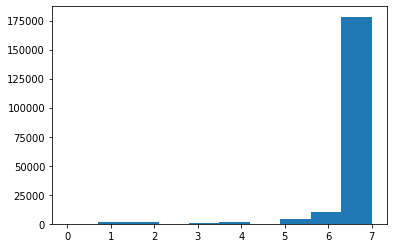

In [153]:
vis = obs_data[:,0]

plt.hist(vis)

In [154]:
# # Sanity check (what would happen if we'd use the actual visibility as model data -> perfect predictions!)
# obs_data = np.expand_dims(obs_data[:,0], axis=1)
# model_data = np.expand_dims(obs_data[:,0], axis=1)

In [155]:
# Use the past_history nr of data to predict future_target nr of data
past_history = 12
future_target = 6

In [156]:
# Indices to select
begin_index = [0] + [48*30*(9+12*i) for i in range(11)]
end_index = [48*30*(2+12*i) for i in range(11)] + [len(obs_data)]

indices = [[i,j] for i, j in zip(begin_index, end_index)]

In [157]:
obs_data_winter = []
model_data_winter = []

for i in range(len(indices)):
  obs_data_winter.append(obs_data[indices[i][0]:indices[i][1],:])
  model_data_winter.append(model_data[indices[i][0]:indices[i][1],:])
obs_data_winter = np.concatenate(obs_data_winter, axis=0)
model_data_winter = np.concatenate(model_data_winter, axis=0)

In [158]:
# Use only winter data
obs_data = obs_data_winter
model_data = model_data_winter

In [159]:
# Split into training data
TRAIN_SPLIT = np.int(0.8*len(obs_data))
print(TRAIN_SPLIT)

68983


### Data preparation

In [160]:
def multivariate_data_model(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
  data = []
  labels = []

  start_index = start_index + history_size
  if end_index is None:
    end_index = len(dataset) - target_size

  for i in range(start_index, end_index):
    indices = range(i-history_size, i+target_size, step)
    data.append(dataset[indices])

    if single_step:
      labels.append(target[i+target_size])
    else:
      labels.append(target[i:i+target_size])

  return np.array(data), np.array(labels)


def multivariate_data_obs(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
  data = []
  labels = []

  start_index = start_index + history_size
  if end_index is None:
    end_index = len(dataset) - target_size

  for i in range(start_index, end_index):
    indices = range(i-history_size, i, step)
    data.append(dataset[indices])

    if single_step:
      labels.append(target[i+target_size])
    else:
      labels.append(target[i:i+target_size])

  return np.array(data), np.array(labels)

In [161]:
STEP = 1

# Split into training and testing data
x_obs_train, y_obs_train = multivariate_data_obs(obs_data, obs_data, 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_obs_test, y_obs_test = multivariate_data_obs(obs_data, obs_data,
                                             TRAIN_SPLIT, None, past_history,
                                             future_target, STEP)

x_model_train, _ = multivariate_data_model(model_data, model_data, 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_model_test, _ = multivariate_data_model(model_data, model_data,
                                             TRAIN_SPLIT, None, past_history,
                                             future_target, STEP)

In [162]:
# Normalize the data (all features except for visibility)
x_obs_min = x_obs_train.min(axis=(0,1))
x_obs_max = x_obs_train.max(axis=(0,1))
x_model_min = x_model_train.min(axis=(0,1))
x_model_max = x_model_train.max(axis=(0,1))

x_obs_train[:,:,1:] = (x_obs_train[:,:,1:]-x_obs_min[1:])/(x_obs_max[1:]-x_obs_min[1:])
x_obs_test[:,:,1:] = (x_obs_test[:,:,1:]-x_obs_min[1:])/(x_obs_max[1:]-x_obs_min[1:])

y_obs_train[:,:,1:] = (y_obs_train[:,:,1:]-x_obs_min[1:])/(x_obs_max[1:]-x_obs_min[1:])
y_obs_test[:,:,1:] = (y_obs_test[:,:,1:]-x_obs_min[1:])/(x_obs_max[1:]-x_obs_min[1:])

x_model_train = (x_model_train-x_model_min)/(x_model_max-x_model_min)
x_model_test = (x_model_test-x_model_min)/(x_model_max-x_model_min)

In [163]:
# Implements over- and undersampling of the data
def resample_data(x_obs, y_obs, x_model, no_classes, samples_per_class):
  
  class_counts = np.zeros(no_classes).astype(np.int32)
  class_indices = []

  a = np.arange(0,len(y_obs),1)

  x_res = np.zeros((sum(samples_per_class), x_obs.shape[1], x_obs.shape[2]))
  y_res = np.zeros((sum(samples_per_class), y_obs.shape[1], y_obs.shape[2]))
  x_res_model = np.zeros((sum(samples_per_class), x_model.shape[1], x_model.shape[2]))

  k = 0
  for i in range(no_classes):

    # Indices of class i in dataset
    curr_class_index = a[np.any(y_obs[:,:,0]==i, axis=1)]

    # Resample class i to have precisely samples_per_class occurrences
    resampled_class_index = resample(curr_class_index, replace=True, 
                                     n_samples=samples_per_class[i])
    samples = len(resampled_class_index)

    x_res[k:k+samples,] = x_obs[resampled_class_index,]
    y_res[k:k+samples,] = y_obs[resampled_class_index,]
    x_res_model[k:k+samples,] = x_model[resampled_class_index,]
    k += samples

  return x_res, y_res, x res_model

In [164]:
class_samples = [5000,3000,3000,10000,1500,1000,8000,10000]
x_obs_res, y_obs_res, x_model_res = resample_data(x_obs_train, y_obs_train, x_model_train, 8, class_samples)

In [165]:
print(x_obs_res.shape, y_obs_res.shape, x_model_res.shape)

(41500, 12, 6) (41500, 6, 6) (41500, 18, 6)


In [166]:
#x_obs_res, y_obs_res, x_model_res = x_obs_train, y_obs_train, x_model_train

In [167]:
print(x_obs_res.shape, y_obs_res.shape, x_model_res.shape)

(41500, 12, 6) (41500, 6, 6) (41500, 18, 6)


(array([[ 1834.,  5026.,  4736.,  3600.,  2921.,  3816.,  6933., 12634.],
        [ 1850.,  5198.,  5003.,  3612.,  3287.,  3719.,  6536., 12295.],
        [ 1832.,  5228.,  5112.,  3484.,  3580.,  3900.,  6170., 12194.],
        [ 1917.,  5074.,  5165.,  3470.,  3646.,  3813.,  6244., 12171.],
        [ 1926.,  5009.,  4960.,  3503.,  3691.,  3628.,  6397., 12386.],
        [ 1915.,  4799.,  4831.,  3431.,  3495.,  3756.,  6531., 12742.]]),
 array([0.  , 0.88, 1.75, 2.62, 3.5 , 4.38, 5.25, 6.12, 7.  ]),
 <a list of 6 Lists of Patches objects>)

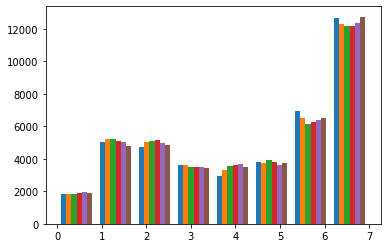

In [168]:
plt.hist(y_obs_res[:,:,0], bins=8)

In [169]:
# Total number of model features
nr_features_model = x_model_res.shape[2]
nr_features_obs = x_obs_res.shape[2]

In [170]:
# Data shape
print ('Single window of past history : {}'.format(x_model_res[0].shape))
print ('Target window to predict : {}'.format(y_obs_res[0].shape))

Single window of past history : (18, 6)
Target window to predict : (6, 6)


In [171]:
from sklearn.utils import compute_class_weight

classes = np.array([i for i in range(8)])
weights = compute_class_weight('balanced', classes, obs_data[:,0])

class_weights = dict(zip(classes, weights))

In [172]:
print(class_weights)

{0: 229.33244680851064, 1: 10.5260009765625, 2: 8.08599024756189, 3: 18.145833333333332, 4: 8.278513824884792, 5: 3.5761861313868613, 6: 1.4473781388478582, 7: 0.15081749874069514}


In [173]:
def multi_layer_cross_entropy(y_true, y_pred):

  t = np.ones(future_target)
  
  loss = t[0]*tf.keras.losses.sparse_categorical_crossentropy(y_true[:,0], y_pred[:,0,:]) + \
  0*tf.cast(tf.keras.losses.mse(y_true[:,0], tf.math.argmax(y_pred[:,0,:], axis=1)), tf.float32)

  for i in range(1, future_target):
    y_true_step_i = y_true[:,i]
    y_pred_step_i = y_pred[:,i,:]
    loss += t[i]*tf.keras.losses.sparse_categorical_crossentropy(y_true_step_i, y_pred_step_i) + \
    0*tf.cast(tf.keras.losses.mse(y_true_step_i, tf.math.argmax(y_pred_step_i, axis=1)), tf.float32)
  return loss

In [174]:
def slice(x, length):
  return x[:,-length:,:]

In [175]:
input_shape_obs = (past_history, nr_features_obs,)
input_shape_model = (past_history+future_target, nr_features_model,)

in_obs = tf.keras.layers.Input(shape=input_shape_obs)
in_model = tf.keras.layers.Input(shape=input_shape_model)

b_obs = tf.keras.layers.LSTM(32, return_sequences=True,
                             recurrent_regularizer=tf.keras.regularizers.l2())(in_obs)
b_obs = tf.keras.layers.Lambda(slice, arguments={'length': 1})(b_obs)
b_obs = tf.keras.layers.Flatten()(b_obs)
b_obs = tf.keras.layers.RepeatVector(future_target)(b_obs)

b_model = tf.keras.layers.LSTM(32, return_sequences=True,
                             recurrent_regularizer=tf.keras.regularizers.l2())(in_model)
b_model = tf.keras.layers.Lambda(slice, arguments={'length': future_target})(b_model)

b = tf.keras.layers.Concatenate(axis=2)([b_obs, b_model])
# b = b_obs
b = tf.keras.layers.LSTM(16, return_sequences=True,
                             recurrent_regularizer=tf.keras.regularizers.l2())(b)
b = tf.keras.layers.LSTM(8, return_sequences=True,
                             recurrent_regularizer=tf.keras.regularizers.l2())(b)
out = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(8, activation='softmax'))(b)

model = tf.keras.models.Model([in_obs, in_model], out)
model.compile(optimizer='adam', loss=multi_layer_cross_entropy, metrics=['acc'])
model.summary()

Model: "model_3"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_7 (InputLayer)            [(None, 12, 6)]      0                                            
__________________________________________________________________________________________________
lstm_12 (LSTM)                  (None, 12, 32)       4992        input_7[0][0]                    
__________________________________________________________________________________________________
lambda_6 (Lambda)               (None, 1, 32)        0           lstm_12[0][0]                    
__________________________________________________________________________________________________
input_8 (InputLayer)            [(None, 18, 6)]      0                                            
____________________________________________________________________________________________

In [176]:
multi_step_history = model.fit([x_obs_res, x_model_res], y_obs_res[:,:,0], 
                               batch_size=256, epochs=20, class_weight=class_weights)

Epoch 1/20
163/163 [==============================] - 7s 8ms/step - loss: 1389.3956 - acc: 0.3608
Epoch 2/20
163/163 [==============================] - 1s 8ms/step - loss: 1091.0981 - acc: 0.4229
Epoch 3/20
163/163 [==============================] - 1s 9ms/step - loss: 1006.2738 - acc: 0.4475
Epoch 4/20
163/163 [==============================] - 1s 8ms/step - loss: 946.1882 - acc: 0.4738
Epoch 5/20
163/163 [==============================] - 1s 8ms/step - loss: 909.6434 - acc: 0.4875
Epoch 6/20
163/163 [==============================] - 1s 8ms/step - loss: 878.0448 - acc: 0.5013
Epoch 7/20
163/163 [==============================] - 1s 9ms/step - loss: 856.0766 - acc: 0.5108
Epoch 8/20
163/163 [==============================] - 1s 9ms/step - loss: 841.7053 - acc: 0.5180
Epoch 9/20
163/163 [==============================] - 1s 9ms/step - loss: 832.5758 - acc: 0.5228
Epoch 10/20
163/163 [==============================] - 1s 8ms/step - loss: 819.8779 - acc: 0.5265
Epoch 11/20
163/163 [=====

In [177]:
def plot_train_history(history, title):
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  epochs = range(len(loss))

  plt.figure()

  plt.plot(epochs, loss, 'b', label='Training loss')
  plt.plot(epochs, val_loss, 'r', label='Validation loss')
  plt.title(title)
  plt.legend()

  plt.show()

In [178]:
# plot_train_history(multi_step_history, 'Multi-Step Training and validation loss')

Text(0, 0.5, 'class')

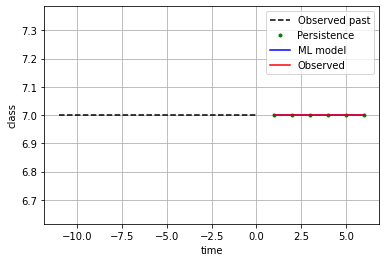

In [179]:
# Plot some results
ix = np.random.randint(0, len(x_obs_test))

vis = np.expand_dims(x_obs_test[ix,:,0], axis=0)
true_vis = np.expand_dims(y_obs_test[ix,:,0], axis=0)

data_obs = np.expand_dims(x_obs_test[ix,:,:], axis=0)
data_model = np.expand_dims(x_model_test[ix,:,:], axis=0)

vis_prob = model([data_obs, data_model])
vis_mean = np.argmax(vis_prob, axis=2)

# This is the input observations
plt.plot(np.arange(-past_history+1, 1), vis[0,:past_history],'k--')

# Persitence prediction
plt.plot(np.arange(1, future_target+1), x_obs_test[ix, past_history-1,0]*np.ones(future_target),'g.')

# ML prediction
plt.plot(np.arange(1, future_target+1), vis_mean[0,],'b')

# True observed future
plt.plot(np.arange(1, future_target+1), true_vis[0,],'r')

plt.legend(['Observed past','Persistence','ML model','Observed']) 
plt.grid()
plt.xlabel('time')
plt.ylabel('class')

# for i in range(runs):
#  plt.plot(np.arange(0, future_target), np.round(vis_prob[i,0,]),'r-.')

In [180]:
def multi_layer_cross_entropy(y_true, y_pred):

  t = np.ones(future_target)

  loss = t[0]*tf.keras.losses.sparse_categorical_crossentropy(y_true[:,0], y_pred[:,0,:]) + \
  tf.cast(tf.keras.losses.mse(y_true[:,0], tf.math.argmax(y_pred[:,0,:], axis=1)), tf.float32)

  for i in range(1, future_target):
    y_true_step_i = y_true[:,i]
    y_pred_step_i = y_pred[:,i,:]
    loss += t[i]*tf.keras.losses.sparse_categorical_crossentropy(y_true_step_i, y_pred_step_i) + \
    tf.cast(tf.keras.losses.mse(y_true_step_i, tf.math.argmax(y_pred_step_i, axis=1)), tf.float32)
  return loss

In [181]:
res = model([data_obs, data_model], training=True)[0,].numpy()
print(res.sum(axis=1))

[1. 1. 1. 1. 1. 1.]


In [182]:
# Proper verification
from sklearn.metrics import *

In [183]:
#Persistence error: [0.1  0.18 0.26 0.33 0.39 0.45]
#ML model error: [0.13 0.2  0.3  0.38 0.44 0.51]

#Persistence error: [0.1  0.18 0.26 0.33 0.39 0.45]
#ML model error: [0.15 0.2  0.29 0.36 0.42 0.49]

#Persistence error: [0.1  0.18 0.26 0.33 0.39 0.45]
#ML model error: [0.12 0.19 0.26 0.32 0.37 0.42]

#Persistence error: [0.1  0.18 0.26 0.33 0.39 0.45]
#ML model error: [0.12 0.19 0.25 0.3  0.34 0.38]

# Now verify the model
# 1) Persistence error
y_pers = np.repeat(np.expand_dims(x_obs_test[:, past_history-1,0], axis=1), future_target, axis=1)
err_pers = np.mean(np.square(y_pers - y_obs_test[:,:,0]), axis=0)

# 3) ML model error
vis_ml = model([x_obs_test, x_model_test])
y_ml = np.argmax(vis_ml, axis=2)
  
err_ml = np.mean(np.square(y_ml - y_obs_test[:,:,0]), axis=0)

print('Persistence error: {}'.format(err_pers))
print('ML model error: {}'.format(err_ml))

Persistence error: [0.1  0.18 0.26 0.33 0.39 0.45]
ML model error: [0.14 0.25 0.39 0.54 0.66 0.78]


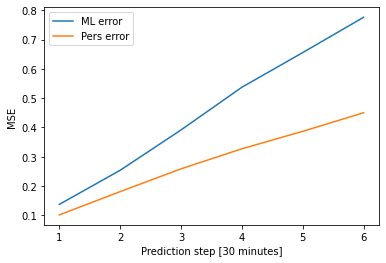

In [184]:
plt.plot(np.arange(1,future_target+1,1), err_ml)
plt.plot(np.arange(1,future_target+1,1), err_pers)
plt.xlabel('Prediction step [30 minutes]')
plt.ylabel('MSE')
plt.legend(['ML error','Pers error'])

In [185]:
nr_classes = 8

precision_pers = np.zeros((nr_classes,future_target))
recall_pers = np.zeros((nr_classes,future_target))
f1_pers = np.zeros((nr_classes,future_target))
balanced_acc_pers = np.zeros(future_target)

precision_ml = np.zeros((nr_classes,future_target))
recall_ml = np.zeros((nr_classes,future_target))
f1_ml = np.zeros((nr_classes,future_target))
balanced_acc_ml = np.zeros(future_target)

for i in range(future_target):
  precision_pers[:,i] = precision_score(y_obs_test[:,i,0], y_pers[:,i], 
                                        labels=[0,1,2,3,4,5,6,7], average=None)
  precision_ml[:,i] = precision_score(y_obs_test[:,i,0], y_ml[:,i], 
                                        labels=[0,1,2,3,4,5,6,7], average=None)

  recall_pers[:,i] = recall_score(y_obs_test[:,i,0], y_pers[:,i], 
                                        labels=[0,1,2,3,4,5,6,7], average=None)
  recall_ml[:,i] = recall_score(y_obs_test[:,i,0], y_ml[:,i], 
                                        labels=[0,1,2,3,4,5,6,7], average=None)

  f1_pers[:,i] = f1_score(y_obs_test[:,i,0], y_pers[:,i], 
                                        labels=[0,1,2,3,4,5,6,7], average=None)
  f1_ml[:,i] = f1_score(y_obs_test[:,i,0], y_ml[:,i], 
                                        labels=[0,1,2,3,4,5,6,7], average=None)
  
  balanced_acc_pers[i] = accuracy_score(y_obs_test[:,i,0], y_pers[:,i])
  balanced_acc_ml[i] = accuracy_score(y_obs_test[:,i,0], y_ml[:,i])

/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [186]:
def categorical_skill_scores(y_true, y_pred, labels=[0,1,2,3,4,5,6,7]):

  # Compute the confusion matrix
  C = confusion_matrix(y_true, y_pred, labels=labels)
  C = C.transpose()
  nr_fcst = np.sum(C, axis=1)
  nr_obs = np.sum(C, axis=0)
  N = np.sum(nr_obs)

  # Heidke skill score
  HSS = (1/N*np.trace(C)-1/N**2*np.sum(nr_fcst*nr_obs))/(1-1/N**2*np.sum(nr_fcst*nr_obs))

  # Peirce skill score
  PSS = (1/N*np.trace(C)-1/N**2*np.sum(nr_fcst*nr_obs))/(1-1/N**2*np.sum(nr_obs**2))

  return HSS, PSS

In [187]:
np.set_printoptions(precision=2)
for i in range(future_target):
  HSS, PSS = categorical_skill_scores(y_obs_test[:,i,0],y_ml[:,i])
  print('Prediction step {}:'.format(i+1))
  print('F1-score ML: {}'.format(f1_ml[:,i]))
  print('F1-score PE: {}'.format(f1_pers[:,i]))
  print('Accuracy ML: {}'.format(np.round(100*balanced_acc_ml[i])/100.0))
  print('Accuracy PE: {}'.format(np.round(100*balanced_acc_pers[i])/100.0))
  print('Heidke skill score ML: {}\nPeirce skill score ML: {}'.format(HSS, PSS))
  HSS, PSS = categorical_skill_scores(y_obs_test[:,i,0],y_pers[:,i])
  print('Heidke skill score PE: {}\nPeirce skill score PE: {}\n'.format(HSS, PSS))

Prediction step 1:
F1-score ML: [0.   0.53 0.44 0.1  0.41 0.11 0.68 0.99]
F1-score PE: [0.   0.62 0.57 0.41 0.42 0.55 0.73 0.99]
Accuracy ML: 0.94
Accuracy PE: 0.95
Heidke skill score ML: 0.6972036992562977
Peirce skill score ML: 0.6829010005892361
Heidke skill score PE: 0.7499437897834562
Peirce skill score PE: 0.7499437897834562

Prediction step 2:
F1-score ML: [0.   0.4  0.37 0.18 0.24 0.16 0.62 0.98]
F1-score PE: [0.   0.48 0.44 0.31 0.33 0.42 0.61 0.98]
Accuracy ML: 0.92
Accuracy PE: 0.93
Heidke skill score ML: 0.6322503552512596
Peirce skill score ML: 0.6319959608244959
Heidke skill score PE: 0.6596079227628983
Peirce skill score PE: 0.6596079227628983

Prediction step 3:
F1-score ML: [0.   0.33 0.3  0.13 0.17 0.08 0.54 0.98]
F1-score PE: [0.   0.39 0.37 0.28 0.29 0.37 0.52 0.98]
Accuracy ML: 0.91
Accuracy PE: 0.91
Heidke skill score ML: 0.5672475051106027
Peirce skill score ML: 0.5688736723475366
Heidke skill score PE: 0.5970258462125116
Peirce skill score PE: 0.5970258462125116

In [188]:
for i in range(future_target):
  print('Classification summary ML model at forecast hour {}:\n'.format(i+1))
  print(classification_report(y_obs_test[:,i,0], y_ml[:,i], labels=[0,1,2,3,4,5,6,7]))
  print('Confusion matrix:\n')
  print(confusion_matrix(y_obs_test[:,i,0], y_ml[:,i], labels=[0,1,2,3,4,5,6,7]))
  print('\n-----------------------------------------------------------')
  print('-----------------------------------------------------------\n')
  print('Classification summary Persistence at forecast hour {}:\n'.format(i+1))
  print(classification_report(y_obs_test[:,i,0], y_pers[:,i], labels=[0,1,2,3,4,5,6,7]))
  print('Confusion matrix:\n')
  print(confusion_matrix(y_obs_test[:,i,0], y_pers[:,i], labels=[0,1,2,3,4,5,6,7]))  
  print('\n')

Classification summary ML model at forecast hour 1:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.43      0.70      0.53        92
           2       0.42      0.47      0.44       164
           3       0.28      0.06      0.10       116
           4       0.39      0.43      0.41       191
           5       0.48      0.06      0.11       383
           6       0.61      0.76      0.68      1044
           7       0.99      0.99      0.99     15237

    accuracy                           0.94     17228
   macro avg       0.45      0.43      0.41     17228
weighted avg       0.93      0.94      0.93     17228

Confusion matrix:

[[    0     1     0     0     0     0     0     0]
 [    0    64    24     0     3     0     1     0]
 [    0    54    77     5    14     2     9     3]
 [    0     9    40     7    46     1    13     0]
 [    0    12    23     9    82    10    53     2]
 [    0     5    10   

/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.34      0.49      0.40        92
           2       0.29      0.51      0.37       164
           3       0.24      0.15      0.18       116
           4       0.22      0.28      0.24       191
           5       0.47      0.09      0.16       383
           6       0.59      0.65      0.62      1044
           7       0.98      0.98      0.98     15237

    accuracy                           0.92     17228
   macro avg       0.39      0.39      0.37     17228
weighted avg       0.92      0.92      0.92     17228

Confusion matrix:

[[    0     0     0     1     0     0     0     0]
 [    7    45    31     1     2     2     4     0]
 [    9    39    83     7     8     2    12     4]
 [    2    11    45    17    29     3     8     1]
 [    2    11    56    20    53     6    38     5]
 [    2    15    39    15    96    36   163    17]
 [    2    10    27    1